# Phân cụm bằng K-Means

Notebook này gồm 4 phần chính:

1. Đọc và tiền xử lý dữ liệu `planets.csv`
2. Cài đặt thuật toán K-Means (không dùng thư viện) để hiểu rõ cơ chế hoạt động bên trong
3. Chọn số cụm k phù hợp, rồi so sánh kết quả với `sklearn.cluster.KMeans` để kiểm chứng
4. Trực quan hóa kết quả cuối cùng

## Bước 1: Đọc và tiền xử lý dữ liệu

- Đọc file `planets.csv`, chỉ giữ lại các hành tinh có đủ 3 giá trị: `orbital_period` (chu kỳ quỹ đạo), `mass` (khối lượng), `distance` (khoảng cách) — dòng nào thiếu 1 trong 3 giá trị này sẽ bị loại.
- 3 đặc trưng này chênh lệch đơn vị rất lớn (chu kỳ tính bằng nghìn ngày, khối lượng tính bằng đơn vị lẻ, khoảng cách tính bằng chục-trăm), nên lấy `log10` trước rồi mới `StandardScaler` để đưa về cùng thang đo. Nếu bỏ qua bước này, đặc trưng có trị số lớn hơn (chu kỳ) sẽ áp đảo phép tính khoảng cách Euclid, khiến kết quả phân cụm bị lệch.

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from IPython.display import display

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

PROJECT_DIR = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "data" / "Sampledata" / "planets.csv").exists()
)
DATA_PATH = PROJECT_DIR / "data" / "Sampledata" / "planets.csv"

df = pd.read_csv(DATA_PATH)
sub = df.dropna(subset=["orbital_period", "mass", "distance"]).copy().reset_index(drop=True)
feat_log = pd.DataFrame({
    "log_orbital_period": np.log10(sub["orbital_period"]),
    "log_mass": np.log10(sub["mass"]),
    "log_distance": np.log10(sub["distance"]),
})
X = StandardScaler().fit_transform(feat_log)
print(f"Đọc dữ liệu từ: {DATA_PATH}")
print(f"Số dòng dùng để phân cụm: {len(sub)} / {len(df)}")

Đọc dữ liệu từ: d:\ml-ai\PCT\data\Sampledata\planets.csv
Số dòng dùng để phân cụm: 498 / 1035


## Bước 2: Cài đặt thuật toán K-Means

Thuật toán K-Means gồm 2 bước lặp:

1. **Gán nhãn**: mỗi điểm được gán vào cụm có tâm gần nhất (khoảng cách Euclid).
2. **Cập nhật tâm cụm**: tâm cụm mới = trung bình cộng của tất cả các điểm đang thuộc cụm đó.

Lặp lại 2 bước trên tới khi nhãn không đổi nữa (hội tụ) hoặc hết `max_iterations`.

In [2]:
def _kmeans_single_run(X, k, max_iterations, rng):
    idx = rng.choice(len(X), k, replace=False)
    centroids = X[idx].copy()
    labels = np.argmin(cdist(X, centroids, "euclidean"), axis=1)

    for _ in range(max_iterations):
        new_centroids = []
        for cluster in range(k):
            points = X[labels == cluster]
            if len(points) == 0:
                new_centroids.append(X[rng.integers(0, len(X))])
            else:
                new_centroids.append(points.mean(axis=0))
        centroids = np.vstack(new_centroids)
        new_labels = np.argmin(cdist(X, centroids, "euclidean"), axis=1)
        if np.array_equal(labels, new_labels):
            break
        labels = new_labels

    inertia = np.sum((X - centroids[labels]) ** 2)
    return labels, centroids, inertia


def kmeans(X, k=4, max_iterations=100, n_init=10, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    best_result = None
    best_inertia = np.inf
    for _ in range(n_init):
        result = _kmeans_single_run(X, k, max_iterations, rng)
        if result[2] < best_inertia:
            best_result = result
            best_inertia = result[2]
    return best_result[0], best_result[1]

## Bước 3: Chọn số cụm k bằng Elbow + Silhouette

- **Elbow (đường xanh, trục trái)**: vẽ `inertia` theo từng giá trị k. Inertia luôn giảm khi k tăng, ta tìm điểm mà đường cong bắt đầu "gãy khúc" (giảm chậm lại) — dấu hiệu cho thấy thêm cụm không còn mang lại lợi ích tương xứng.
- **Silhouette score (đường đỏ, trục phải)**: đo mức độ tách biệt giữa các cụm, giá trị càng gần 1 càng tốt (cụm chặt và tách biệt rõ), càng gần 0 hoặc âm càng cho thấy cụm bị chồng lấn.
- **Chọn k**: chọn `K_CHOSEN` **tự động** bằng k có silhouette score cao nhất (`np.argmax(sil_scores)`). Đây là cách chọn khách quan, nhưng silhouette cao nhất đôi khi ứng với cách chia khá thô (k nhỏ) — nên vẫn nên nhìn thêm cả đường elbow để đối chiếu trực quan, thay vì tin tuyệt đối vào con số tự động này.

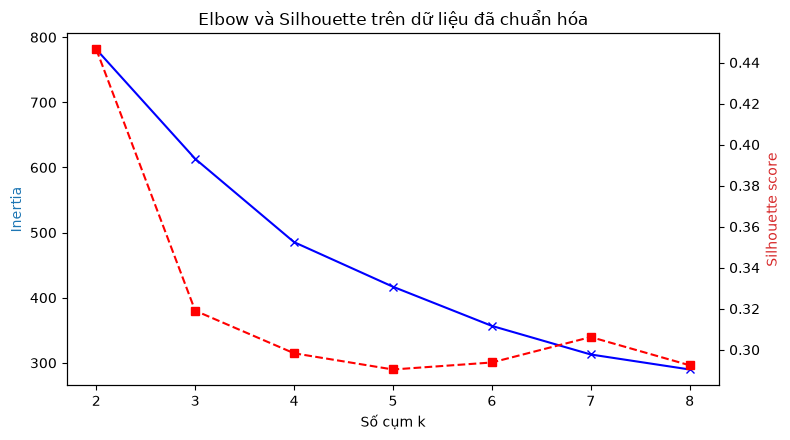

Chọn k = 2 theo silhouette score cao nhất


In [3]:
K_range = range(2, 9)
distortions, sil_scores = [], []
for k in K_range:
    model = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = model.fit_predict(X)
    distortions.append(model.inertia_)
    sil_scores.append(silhouette_score(X, labels))

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(list(K_range), distortions, "bx-")
ax1.set_xlabel("Số cụm k")
ax1.set_ylabel("Inertia", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(list(K_range), sil_scores, "rs--")
ax2.set_ylabel("Silhouette score", color="tab:red")
ax1.set_title("Elbow và Silhouette trên dữ liệu đã chuẩn hóa")
fig.tight_layout()
plt.show()

K_CHOSEN = list(K_range)[int(np.argmax(sil_scores))]
print(f"Chọn k = {K_CHOSEN} theo silhouette score cao nhất")

## Bước 4: Chạy K-Means và so sánh với thư viện scikit-learn

- Chạy hàm `kmeans()` đã viết ở Bước 2 với `k = K_CHOSEN`.
- Chạy song song `sklearn.cluster.KMeans` với cùng `k` để đối chiếu.
- **Adjusted Rand Index (ARI)**: đo mức độ giống nhau giữa 2 cách phân cụm — giá trị 1.0 là khớp hoàn toàn, 0 là ngẫu nhiên. ARI càng gần 1 chứng tỏ code được cài đặt cho kết quả tương đương thư viện chuẩn.
- **Bảng chéo (crosstab)**: đối chiếu trực tiếp nhãn cụm giữa 2 phương pháp. Lưu ý nhãn số (0,1,2,3...) chỉ là "tên gọi" ngẫu nhiên — cụm số 0 của code tự viết có thể tương ứng với cụm số 2 của sklearn. Mỗi hàng/cột trong bảng chéo dồn áp đảo vào đúng 1 ô là dấu hiệu 2 cách phân cụm khớp nhau tốt.

In [4]:
P_custom, centroids_custom = kmeans(
    X, k=K_CHOSEN, max_iterations=100, n_init=10, rng=rng
)

sk_km = KMeans(
    n_clusters=K_CHOSEN,
    init="random",
    n_init=10,
    max_iter=100,
    random_state=RANDOM_SEED,
)
P_sklearn = sk_km.fit_predict(X)

ari = adjusted_rand_score(P_custom, P_sklearn)
print(f"Adjusted Rand Index (custom vs sklearn): {ari:.3f}")
display(pd.crosstab(
    P_custom,
    P_sklearn,
    rownames=["custom"],
    colnames=["sklearn"],
))

Adjusted Rand Index (custom vs sklearn): 1.000


sklearn,0,1
custom,,
0,168,0
1,0,330


## Bước 5: Trực quan hóa kết quả phân cụm

Vẽ các hành tinh lên biểu đồ `chu kỳ quỹ đạo` (trục x) và `khối lượng` (trục y), tô màu theo cụm mà K-Means tự viết đã gán. Cả 2 trục dùng thang log vì dữ liệu trải dài nhiều bậc độ lớn (ví dụ chu kỳ từ 1 tới hơn 17.000 ngày) — nếu vẽ thang thường, phần lớn điểm sẽ dồn cục ở góc trái, khó nhìn ra ranh giới giữa các cụm.

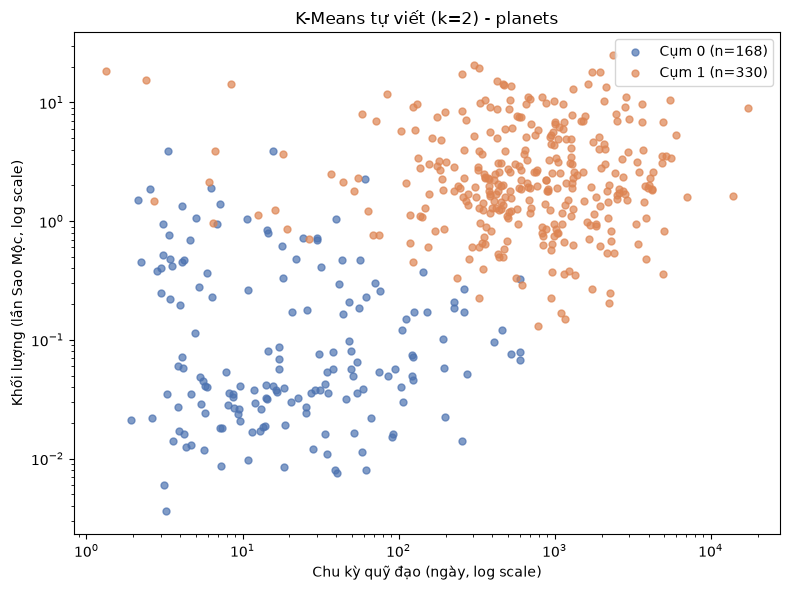

In [5]:
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860", "#DA8BC3", "#8C8C8C"]
plt.figure(figsize=(8, 6))
for cluster in range(K_CHOSEN):
    points = sub[P_custom == cluster]
    plt.scatter(
        points["orbital_period"],
        points["mass"],
        s=25,
        alpha=0.7,
        color=colors[cluster % len(colors)],
        label=f"Cụm {cluster} (n={len(points)})",
    )
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Chu kỳ quỹ đạo (ngày, log scale)")
plt.ylabel("Khối lượng (lần Sao Mộc, log scale)")
plt.title(f"K-Means tự viết (k={K_CHOSEN}) - planets")
plt.legend()
plt.tight_layout()
plt.show()